# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFECV
from sklearn.svm import SVR
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Import Dataset

In [2]:
Train_Data = np.genfromtxt('train_FD001.txt')
Test_Data = np.genfromtxt('test_FD001.txt')
RUL_Test_Data = np.genfromtxt('RUL_FD001.txt')

In [3]:
print('Sahpe of Train Dataset: {}' .format(Train_Data.shape))
print('Sahpe of Test Dataset: {}' .format(Test_Data.shape))
print('Sahpe of RUL Test Dataset: {}' .format(RUL_Test_Data.shape))

Sahpe of Train Dataset: (20631, 26)
Sahpe of Test Dataset: (13096, 26)
Sahpe of RUL Test Dataset: (100,)


In [4]:
columns_names = ['unit_number','time_in_cycles', 'op_set_1','op_set_2','op_set_3','sensor_1','sensor_2','sensor_3',
                 'sensor_4','sensor_5','sensor_6','sensor_7','sensor_8','sensor_9','sensor_10','sensor_11','sensor_12',
                 'sensor_13','sensor_14','sensor_15','sensor_16','sensor_17','sensor_18','sensor_19','sensor_20','sensor_21']

In [5]:
df_Train_Data = pd.DataFrame(Train_Data, columns=columns_names)
df_Test_Data = pd.DataFrame(Test_Data, columns=columns_names)
df_RUL_Test_Data = pd.Series(RUL_Test_Data)

# Initial data analysis

In [6]:
# Train

df_Train_Data

,unit_number,time_in_cycles,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1.0,1.0,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190
1,1.0,2.0,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236
2,1.0,3.0,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442
3,1.0,4.0,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739
4,1.0,5.0,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,196.0,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397.0,2388.0,100.0,38.49,22.9735
20627,100.0,197.0,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395.0,2388.0,100.0,38.30,23.1594
20628,100.0,198.0,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398.0,2388.0,100.0,38.44,22.9333
20629,100.0,199.0,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395.0,2388.0,100.0,38.29,23.0640


### type of each column

In [7]:
df_Train_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  float64
 1   time_in_cycles  20631 non-null  float64
 2   op_set_1        20631 non-null  float64
 3   op_set_2        20631 non-null  float64
 4   op_set_3        20631 non-null  float64
 5   sensor_1        20631 non-null  float64
 6   sensor_2        20631 non-null  float64
 7   sensor_3        20631 non-null  float64
 8   sensor_4        20631 non-null  float64
 9   sensor_5        20631 non-null  float64
 10  sensor_6        20631 non-null  float64
 11  sensor_7        20631 non-null  float64
 12  sensor_8        20631 non-null  float64
 13  sensor_9        20631 non-null  float64
 14  sensor_10       20631 non-null  float64
 15  sensor_11       20631 non-null  float64
 16  sensor_12       20631 non-null  float64
 17  sensor_13       20631 non-null 

### descriptive statistics

In [8]:
df_Train_Data.iloc[:,2:].describe().iloc[:,:15]

,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12
count,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000
mean,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.300000e+00,47.541168,521.413470
std,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,0.001389,0.885092,0.070985,22.082880,4.660829e-13,0.267087,0.737553
min,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.300000e+00,46.850000,518.690000
25%,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.300000e+00,47.350000,520.960000
50%,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.300000e+00,47.510000,521.480000
75%,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.300000e+00,47.700000,521.950000
max,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.300000e+00,48.530000,523.380000


In [9]:
df_Train_Data.iloc[:,2:].describe().iloc[:,15:]

,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


### check for nan values

In [10]:
df_Train_Data.isnull().sum() 

unit_number       0
time_in_cycles    0
op_set_1          0
op_set_2          0
op_set_3          0
sensor_1          0
sensor_2          0
sensor_3          0
sensor_4          0
sensor_5          0
sensor_6          0
sensor_7          0
sensor_8          0
sensor_9          0
sensor_10         0
sensor_11         0
sensor_12         0
sensor_13         0
sensor_14         0
sensor_15         0
sensor_16         0
sensor_17         0
sensor_18         0
sensor_19         0
sensor_20         0
sensor_21         0
dtype: int64

### remove column with zero or near zero variance

In [11]:
# Calculate Variance for each column

variance = np.std(df_Train_Data,axis=0).sort_values()
variance

sensor_19         0.000000e+00
op_set_3          0.000000e+00
sensor_18         0.000000e+00
sensor_16         1.556394e-14
sensor_10         4.660716e-13
sensor_5          3.394618e-12
sensor_1          6.536993e-11
op_set_2          2.930550e-04
sensor_6          1.388951e-03
op_set_1          2.187260e-03
sensor_15         3.750413e-02
sensor_8          7.098376e-02
sensor_13         7.191717e-02
sensor_21         1.082483e-01
sensor_20         1.807420e-01
sensor_11         2.670809e-01
sensor_2          5.000412e-01
sensor_12         7.375355e-01
sensor_7          8.850708e-01
sensor_17         1.548725e+00
sensor_3          6.131001e+00
sensor_4          9.000387e+00
sensor_14         1.907571e+01
sensor_9          2.208234e+01
unit_number       2.922692e+01
time_in_cycles    6.887932e+01
dtype: float64

In [12]:
Mean = df_Train_Data[variance[:10].index].mean()
print('Mean of the 10 Features with the Lowest Variance:\n{} \n'.format(Mean))
print('10 Features with the Lowest Variance:\n{}'.format(variance[:10]))

Mean of the 10 Features with the Lowest Variance:
sensor_19     100.000000
op_set_3      100.000000
sensor_18    2388.000000
sensor_16       0.030000
sensor_10       1.300000
sensor_5       14.620000
sensor_1      518.670000
op_set_2        0.000002
sensor_6       21.609803
op_set_1       -0.000009
dtype: float64 

10 Features with the Lowest Variance:
sensor_19    0.000000e+00
op_set_3     0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556394e-14
sensor_10    4.660716e-13
sensor_5     3.394618e-12
sensor_1     6.536993e-11
op_set_2     2.930550e-04
sensor_6     1.388951e-03
op_set_1     2.187260e-03
dtype: float64


In [13]:
print('10 Features with the Lowest Variance are removed:\n{}'.format(variance[:10].index.to_list()))

10 Features with the Lowest Variance are removed:
['sensor_19', 'op_set_3', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1', 'op_set_2', 'sensor_6', 'op_set_1']


In [14]:
df_Train_Data.drop(columns=variance[:10].index.to_list(), inplace=True)
df_Test_Data.drop(columns=variance[:10].index.to_list(), inplace=True)

# Analyze Degradation Patterns

In [15]:
# Choose 10 random engines to plot their sensors

engine_id = df_Train_Data['unit_number'].unique()
selected_random_engine_id = np.random.choice(engine_id, size=7, replace=False)

In [16]:
print('number of train columns: {}'.format(df_Train_Data.shape[1]))
print('name of train columns: {}'.format(df_Train_Data.columns.to_list()))

number of train columns: 16
name of train columns: ['unit_number', 'time_in_cycles', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


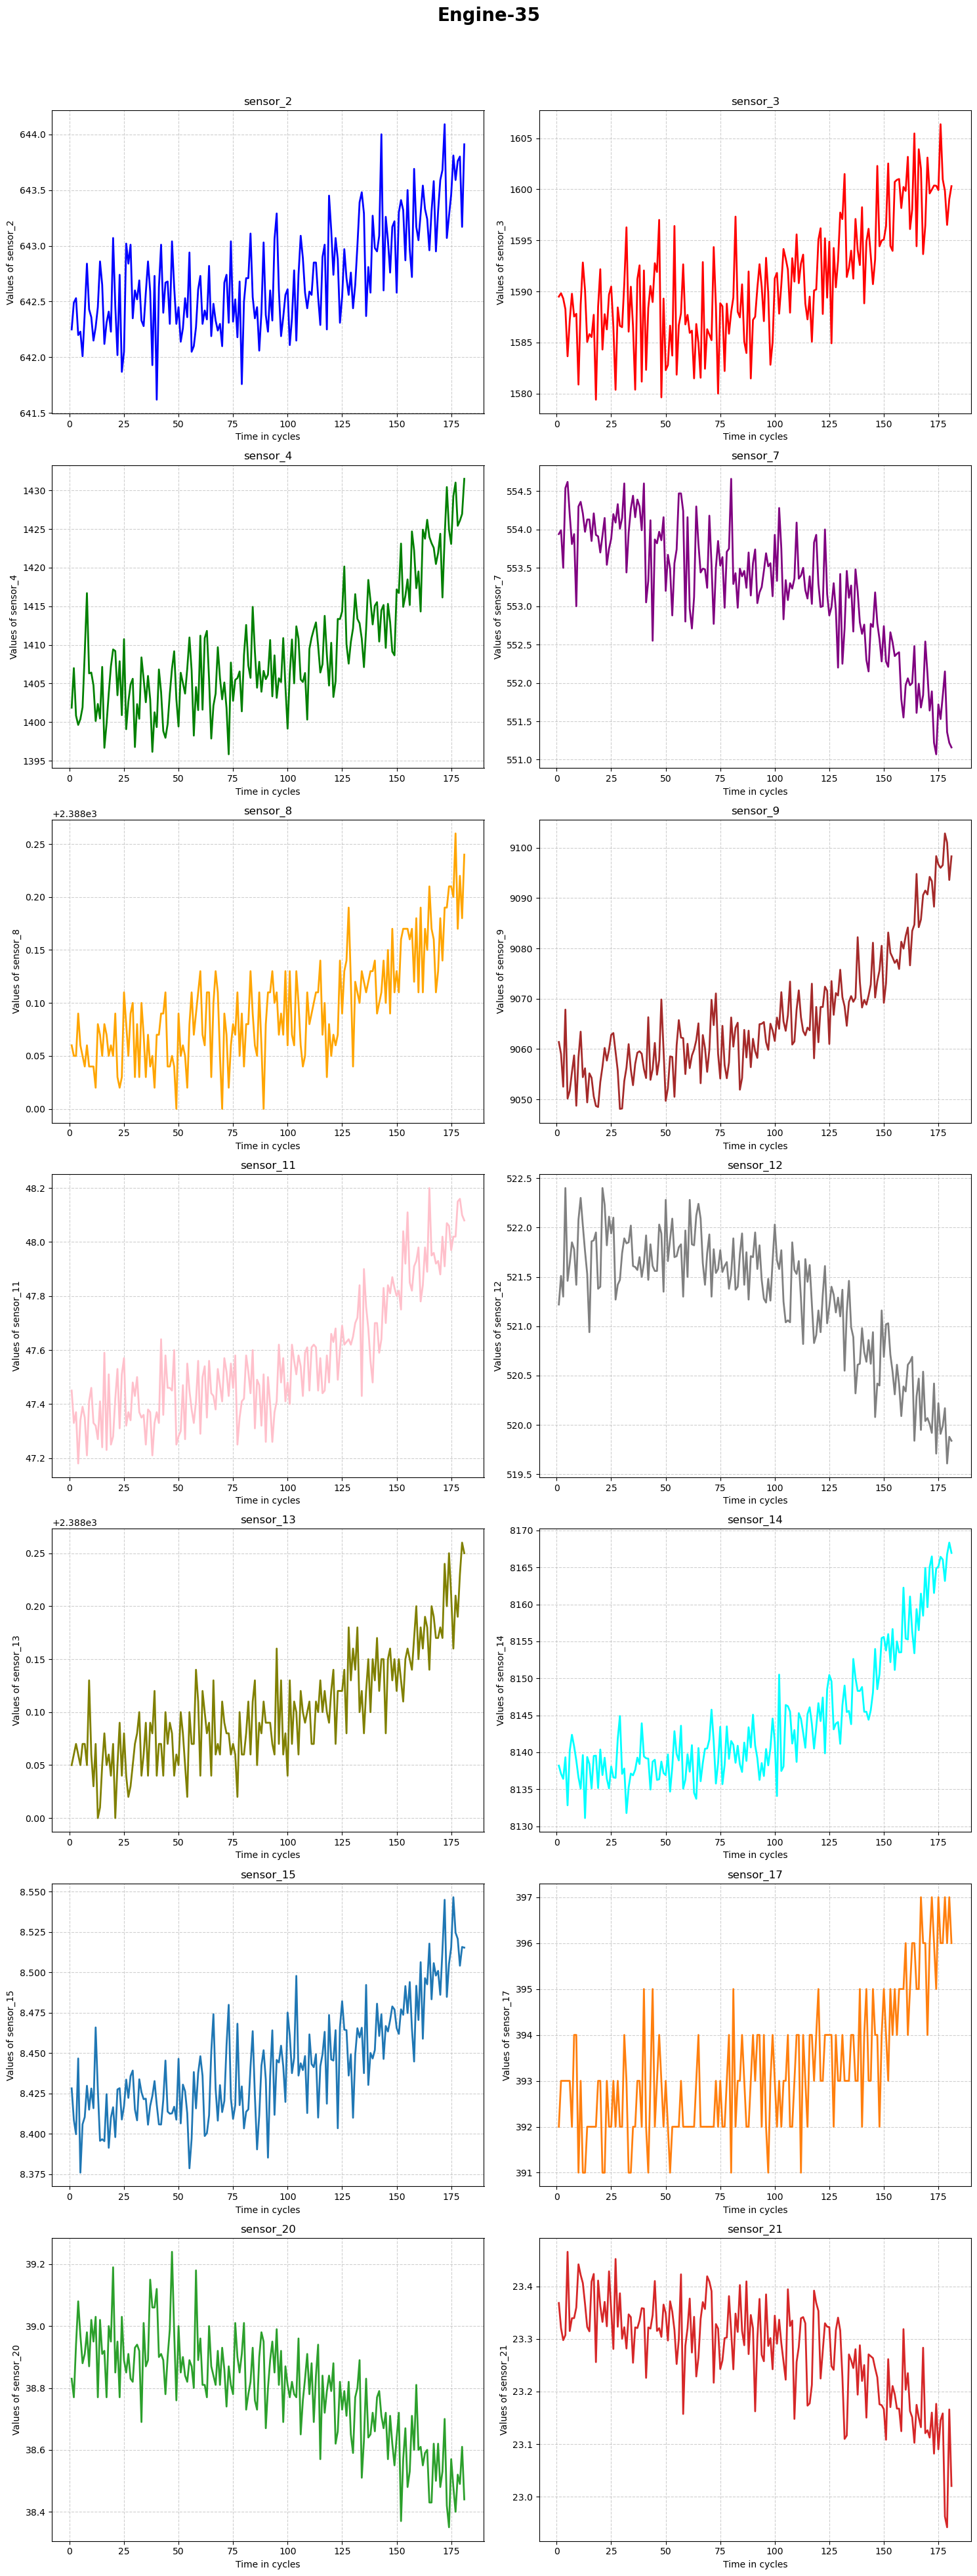

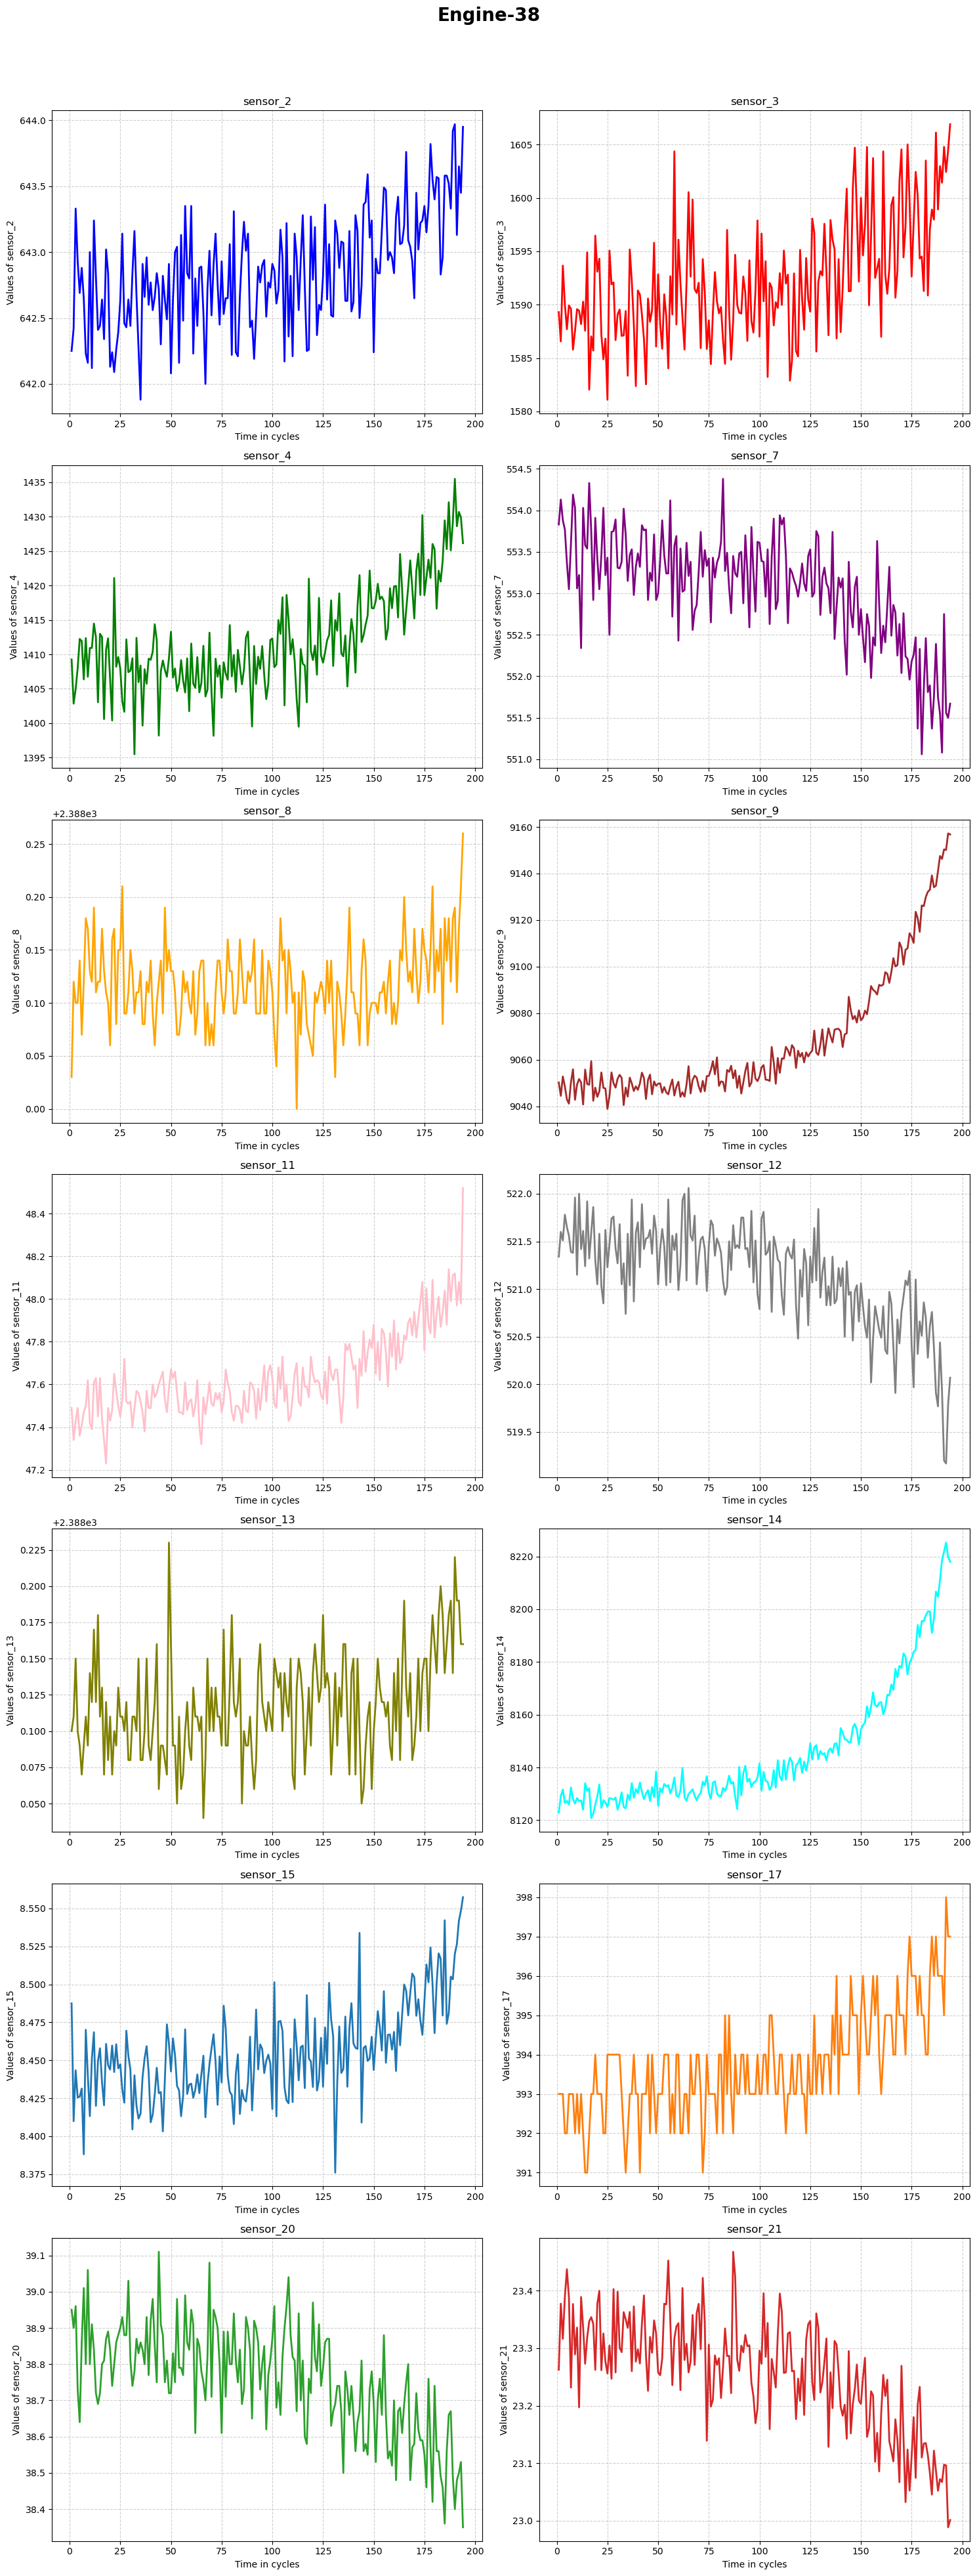

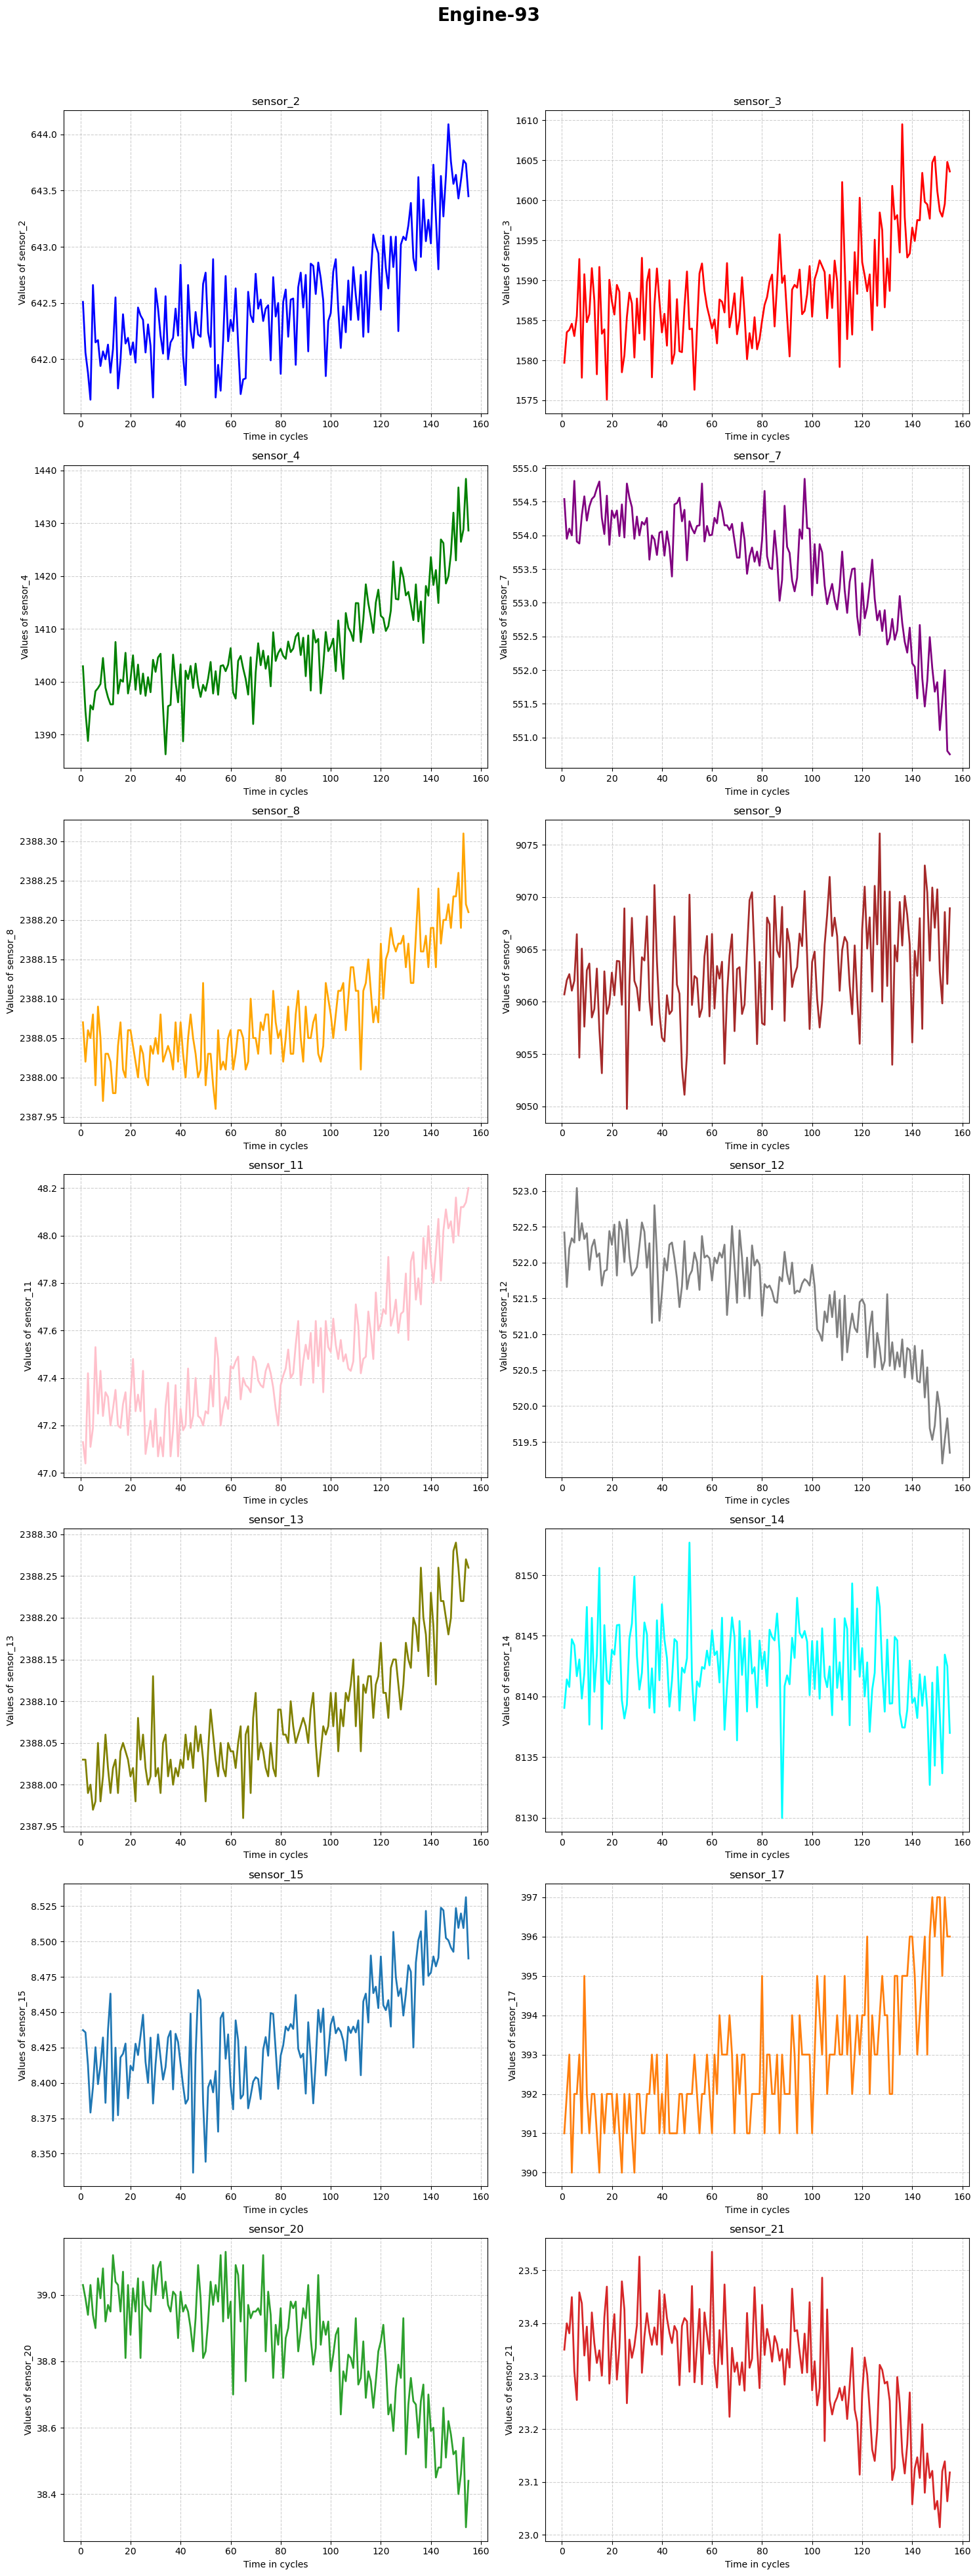

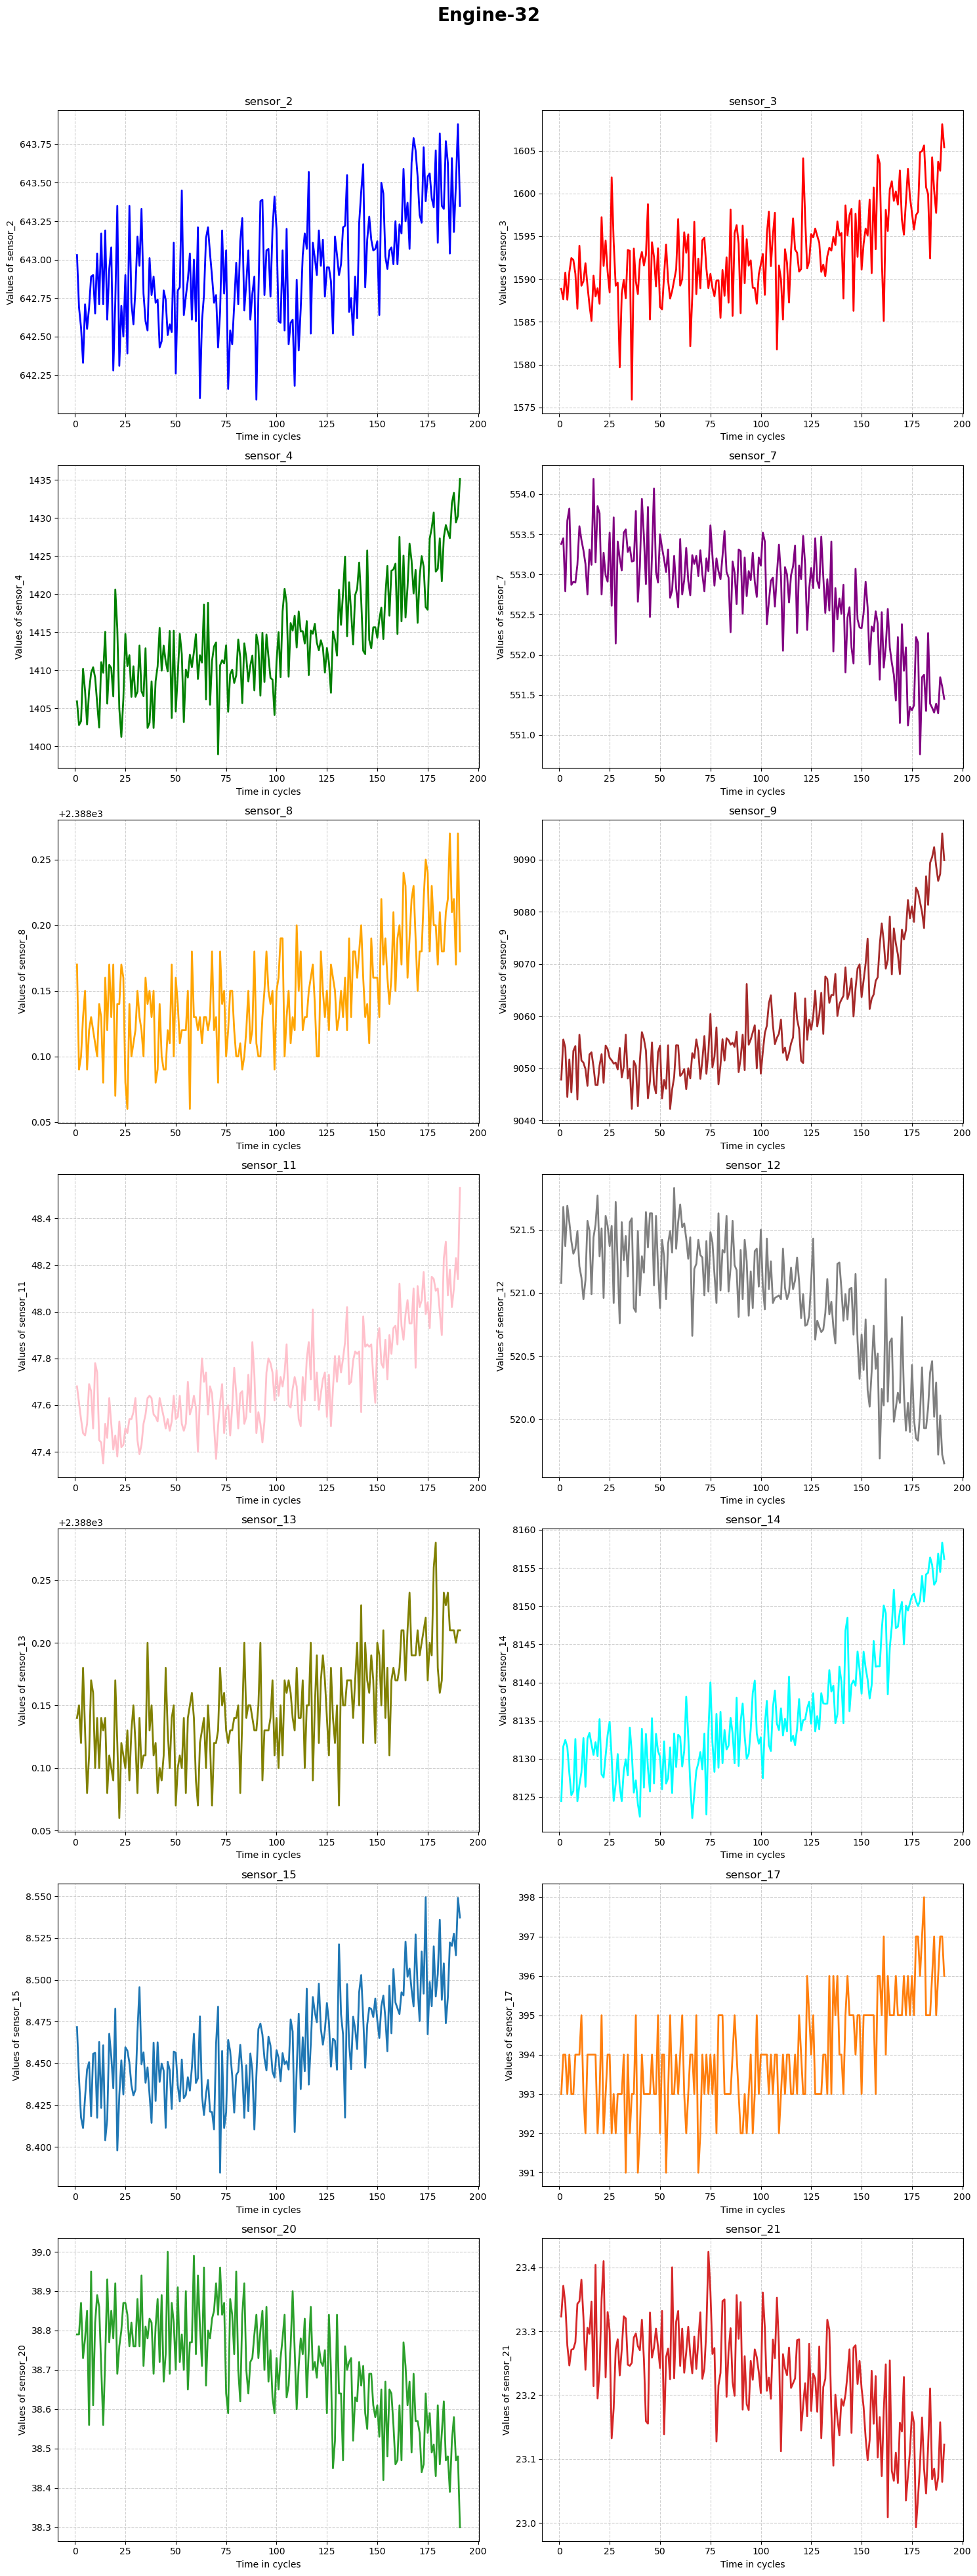

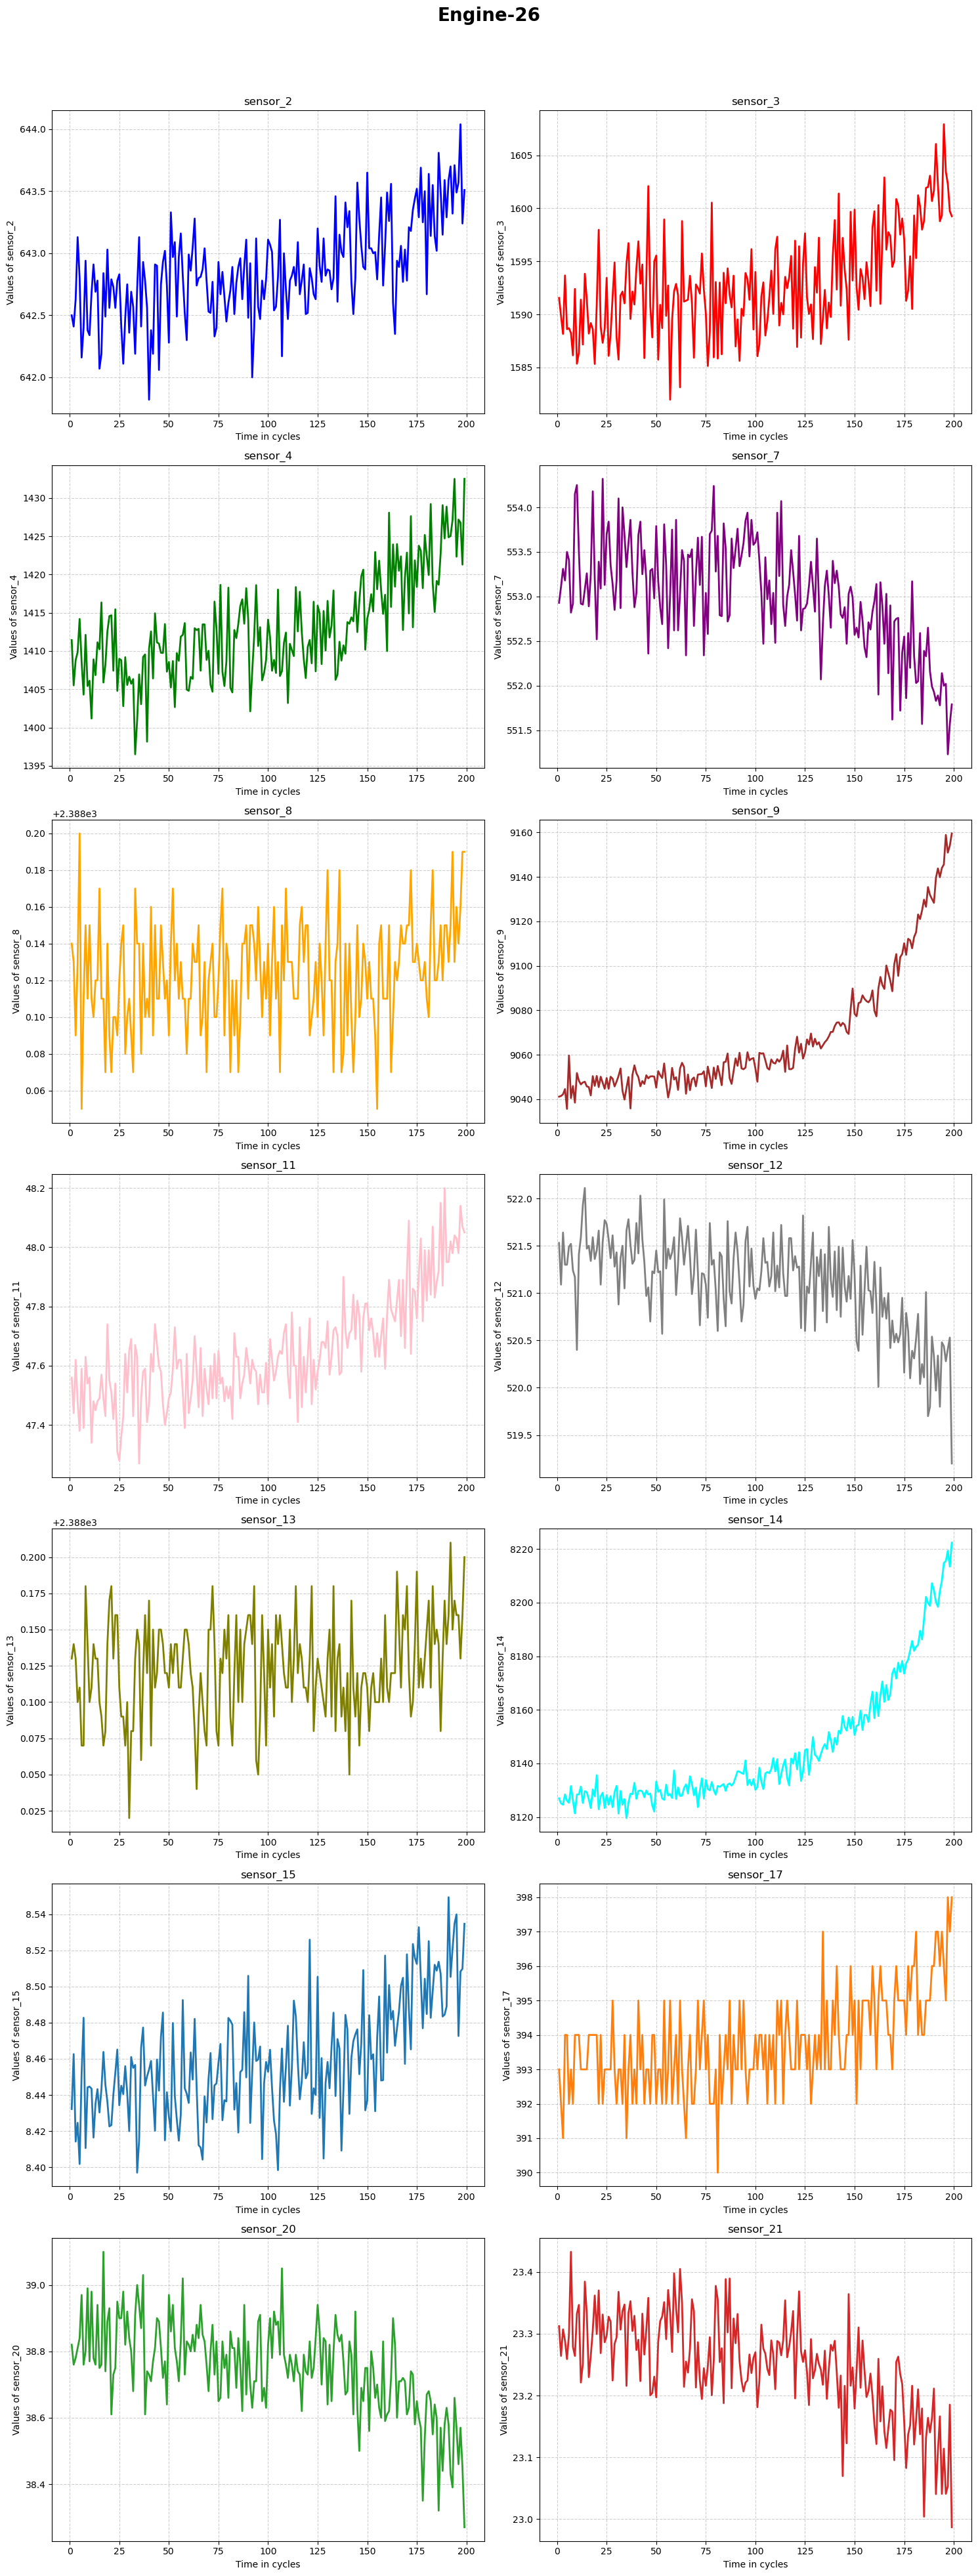

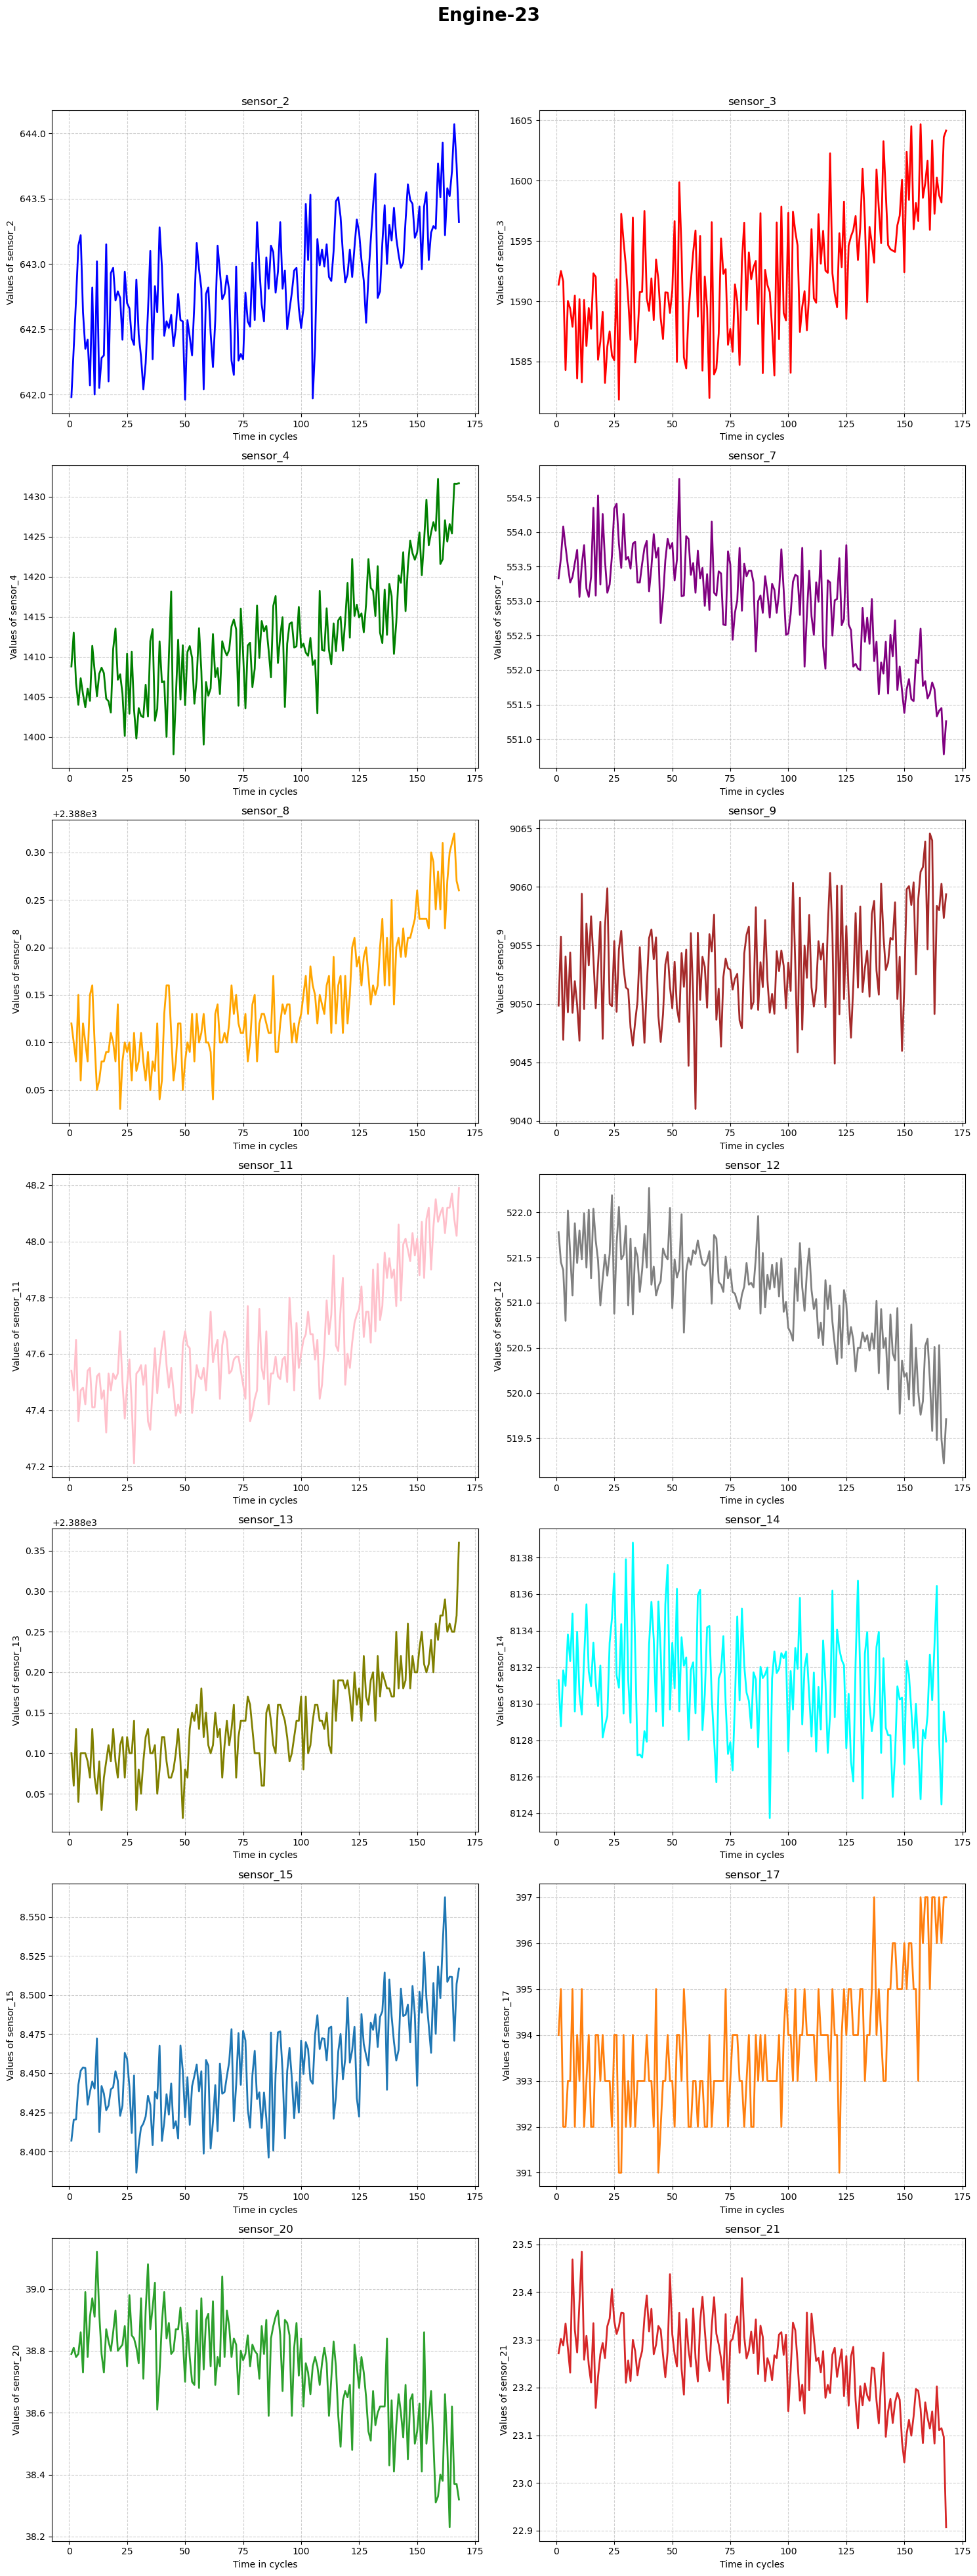

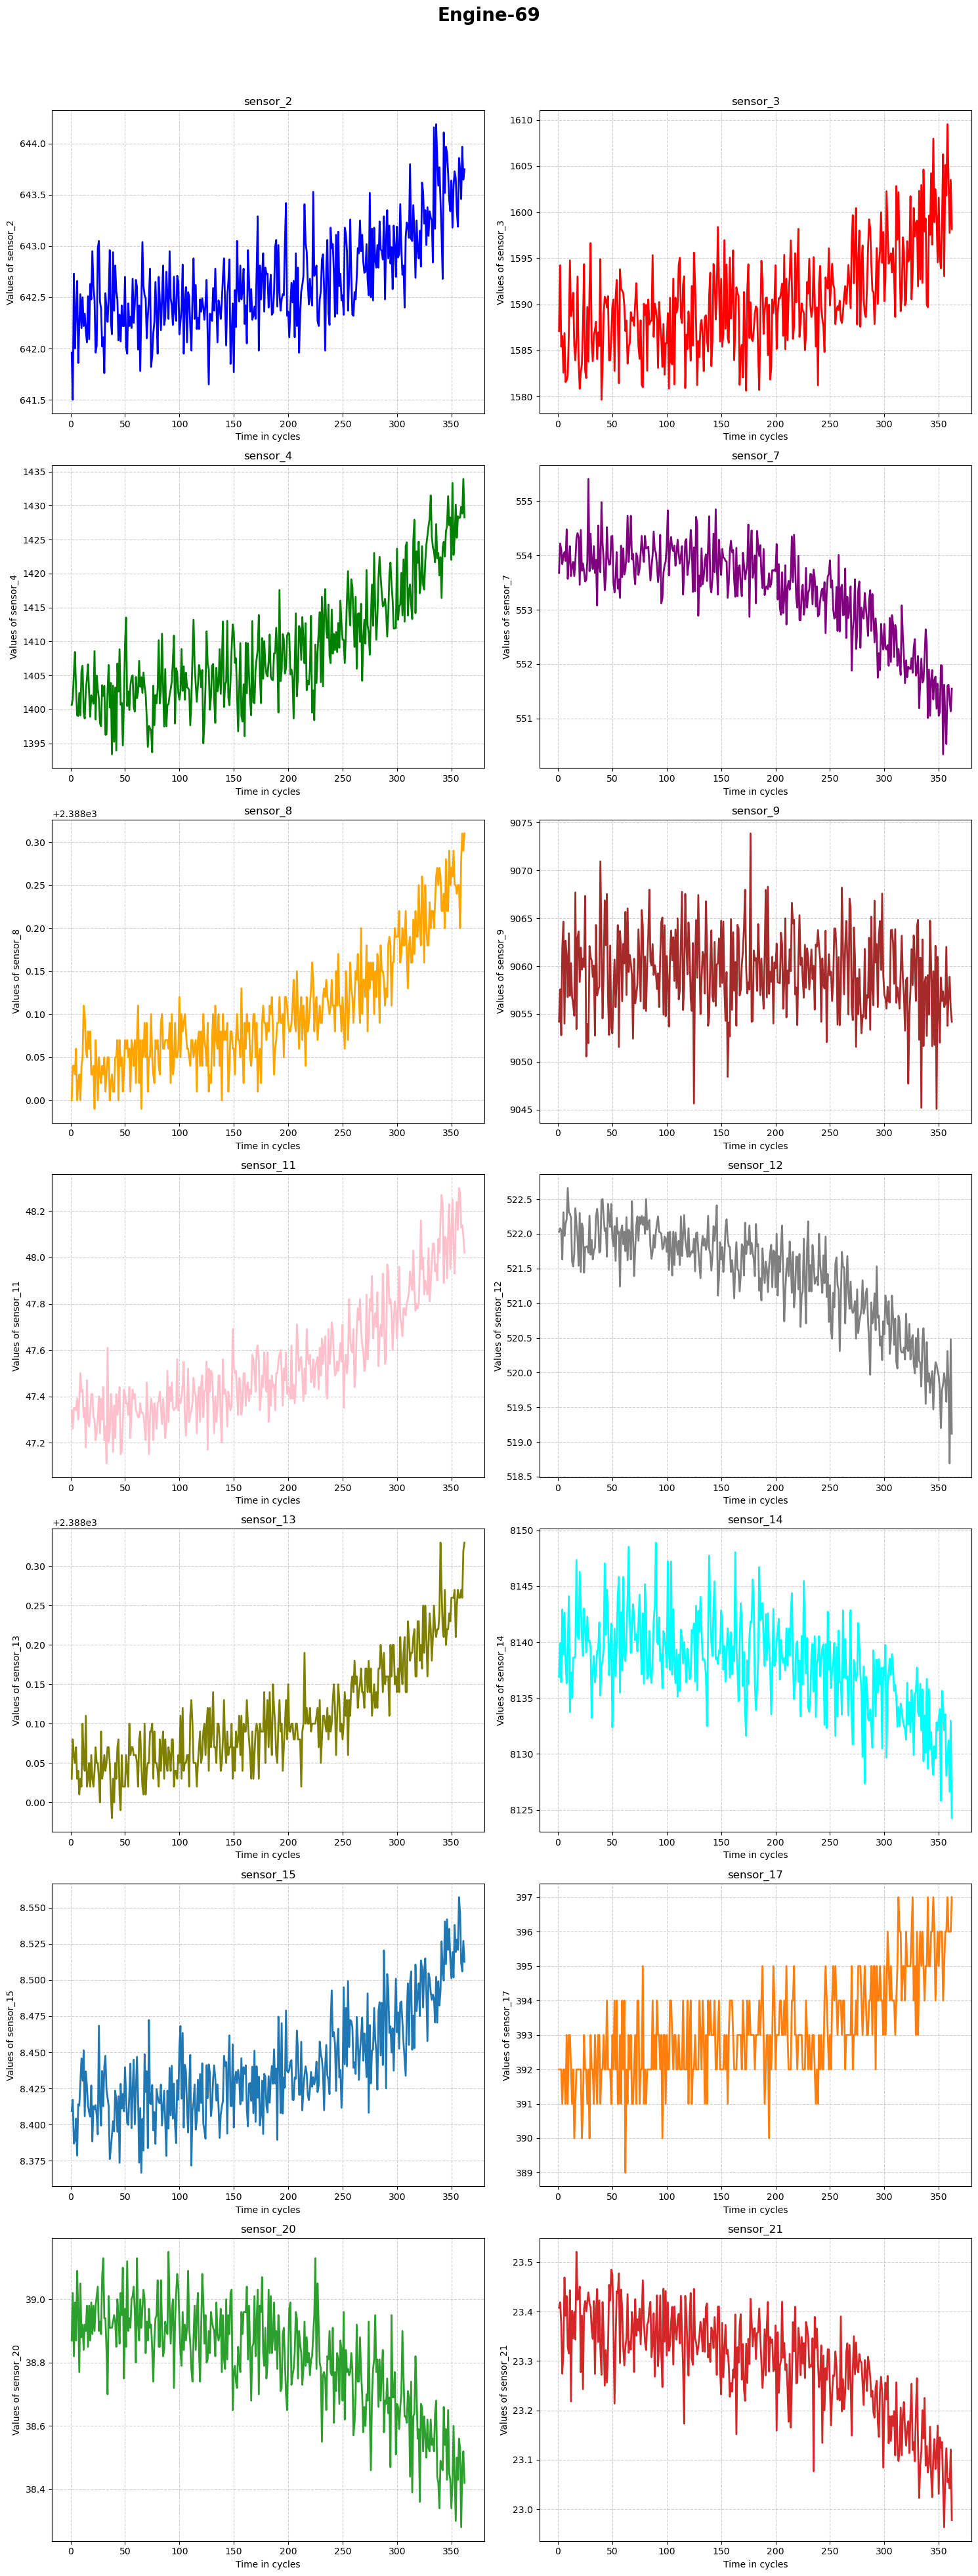

In [17]:
PLOT_COLORS = [
    'blue', 'red', 'green', 'purple', 
    'orange', 'brown', 'pink', 'gray', 
    'olive', 'cyan', '#1f77b4', '#ff7f0e',
    '#2ca02c', '#d62728' 
]

for id in selected_random_engine_id:

    random_engine_samples = df_Train_Data[df_Train_Data['unit_number'].isin([id])]
    fig, axes = plt.subplots(7, 2, figsize = (15,40))
    fig.suptitle(f'Engine-{int(id)}', fontsize = 20, weight='bold')

    all_axes = axes.flatten() 

    for ax in range(14):
        current_ax = all_axes[ax]
        columns_number = ax+2
        current_ax.plot(random_engine_samples['time_in_cycles'], random_engine_samples.iloc[0:,columns_number],
                         color= PLOT_COLORS[ax], linewidth = 2)
        
        current_ax.grid(True, linestyle = '--', alpha=0.6)
        current_ax.set_title(f'{df_Train_Data.columns.to_list()[columns_number]}')
        current_ax.set_xlabel('Time in cycles')
        current_ax.set_ylabel('Values of {}'.format(df_Train_Data.columns.to_list()[columns_number]))

        plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()        

# Feature Engineering

In [18]:
# create total lifetime
total_lifetime = df_Train_Data.groupby(['unit_number']).size()
repeated_total_lifetime = total_lifetime.repeat(total_lifetime.values)
print(f'Total_lifetime:\n {total_lifetime}')

# Insert into Train Data
df_Train_Data.insert(loc=2, column='max_lifetime', value=repeated_total_lifetime.values)

Total_lifetime:
 unit_number
1.0      192
2.0      287
3.0      179
4.0      189
5.0      269
        ... 
96.0     336
97.0     202
98.0     156
99.0     185
100.0    200
Length: 100, dtype: int64


In [19]:
df_Train_Data

,unit_number,time_in_cycles,max_lifetime,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1.0,1.0,192,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190
1,1.0,2.0,192,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236
2,1.0,3.0,192,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442
3,1.0,4.0,192,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392.0,38.88,23.3739
4,1.0,5.0,192,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,196.0,200,643.49,1597.98,1428.63,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397.0,38.49,22.9735
20627,100.0,197.0,200,643.54,1604.50,1433.58,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395.0,38.30,23.1594
20628,100.0,198.0,200,643.42,1602.46,1428.18,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398.0,38.44,22.9333
20629,100.0,199.0,200,643.23,1605.26,1426.53,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395.0,38.29,23.0640


In [20]:
# create RUL
RUL = df_Train_Data['max_lifetime'] - df_Train_Data['time_in_cycles']

# Insert into Train Data
df_Train_Data.insert(loc=3, column='RUL', value=RUL)
df_Train_Data

,unit_number,time_in_cycles,max_lifetime,RUL,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1.0,1.0,192,191.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190
1,1.0,2.0,192,190.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236
2,1.0,3.0,192,189.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442
3,1.0,4.0,192,188.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392.0,38.88,23.3739
4,1.0,5.0,192,187.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,196.0,200,4.0,643.49,1597.98,1428.63,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397.0,38.49,22.9735
20627,100.0,197.0,200,3.0,643.54,1604.50,1433.58,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395.0,38.30,23.1594
20628,100.0,198.0,200,2.0,643.42,1602.46,1428.18,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398.0,38.44,22.9333
20629,100.0,199.0,200,1.0,643.23,1605.26,1426.53,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395.0,38.29,23.0640


In [21]:
# piece-wise RUL - clip RUL  :: Because Engine does not degrade linearly from its first uses. In early stages it is considered healthy and degradation is developed and 
# observed at cycles closer to failure.

df_Train_Data['RUL'] = df_Train_Data['RUL'].clip(upper=125)
df_Train_Data

,unit_number,time_in_cycles,max_lifetime,RUL,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1.0,1.0,192,125.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190
1,1.0,2.0,192,125.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236
2,1.0,3.0,192,125.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442
3,1.0,4.0,192,125.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392.0,38.88,23.3739
4,1.0,5.0,192,125.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,196.0,200,4.0,643.49,1597.98,1428.63,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397.0,38.49,22.9735
20627,100.0,197.0,200,3.0,643.54,1604.50,1433.58,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395.0,38.30,23.1594
20628,100.0,198.0,200,2.0,643.42,1602.46,1428.18,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398.0,38.44,22.9333
20629,100.0,199.0,200,1.0,643.23,1605.26,1426.53,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395.0,38.29,23.0640


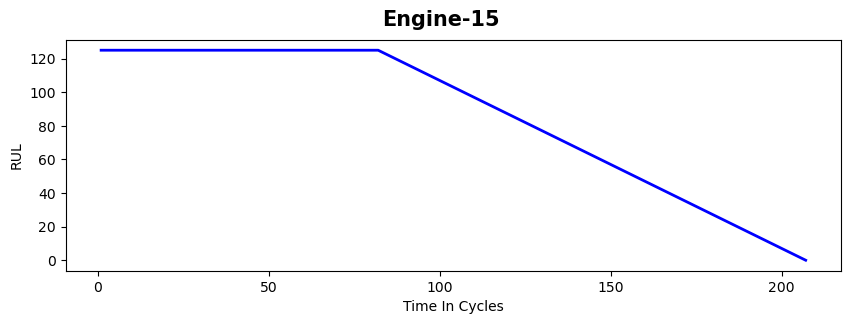

Maximum Lifetime of Engine-15: 207


In [22]:
# Plot RUL - time_in_cycles for one random engine

Number_Of_Engine = 15

fig = plt.figure(figsize = (10,3))

fig.suptitle(f'Engine-{Number_Of_Engine}', fontsize=15, weight='bold')
engine15_data = df_Train_Data[df_Train_Data['unit_number'].isin([Number_Of_Engine])]

plt.plot(engine15_data['time_in_cycles'],engine15_data['RUL'], linewidth=2, color='blue')

plt.xlabel('Time In Cycles')
plt.ylabel('RUL')
plt.show()

print('Maximum Lifetime of Engine-{}: {}'.format(Number_Of_Engine,engine15_data.iloc[0,engine15_data.columns.get_loc('max_lifetime')]))

In [23]:
print('Number of Train columns: {}'.format(df_Train_Data.shape[1]))
print('Number of Test columns: {}'.format(df_Test_Data.shape[1]))
print('Number of Train Data: {}'.format(df_Train_Data.shape[0]))
print('Number of Test Data: {}'.format(df_Test_Data.shape[0]))

Number of Train columns: 18
Number of Test columns: 16
Number of Train Data: 20631
Number of Test Data: 13096


# Normalizing

In [24]:
df_Train_Data

,unit_number,time_in_cycles,max_lifetime,RUL,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1.0,1.0,192,125.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190
1,1.0,2.0,192,125.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236
2,1.0,3.0,192,125.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442
3,1.0,4.0,192,125.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392.0,38.88,23.3739
4,1.0,5.0,192,125.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,196.0,200,4.0,643.49,1597.98,1428.63,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397.0,38.49,22.9735
20627,100.0,197.0,200,3.0,643.54,1604.50,1433.58,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395.0,38.30,23.1594
20628,100.0,198.0,200,2.0,643.42,1602.46,1428.18,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398.0,38.44,22.9333
20629,100.0,199.0,200,1.0,643.23,1605.26,1426.53,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395.0,38.29,23.0640


In [25]:
df_Test_Data

,unit_number,time_in_cycles,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1.0,1.0,643.02,1585.29,1398.21,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392.0,38.86,23.3735
1,1.0,2.0,641.71,1588.45,1395.42,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393.0,39.02,23.3916
2,1.0,3.0,642.46,1586.94,1401.34,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393.0,39.08,23.4166
3,1.0,4.0,642.44,1584.12,1406.42,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391.0,39.00,23.3737
4,1.0,5.0,642.51,1587.19,1401.92,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100.0,194.0,643.24,1599.45,1415.79,553.41,2388.02,9142.37,47.69,520.69,2388.00,8213.28,8.4715,394.0,38.65,23.1974
13092,100.0,195.0,643.22,1595.69,1422.05,553.22,2388.05,9140.68,47.60,521.05,2388.09,8210.85,8.4512,395.0,38.57,23.2771
13093,100.0,196.0,643.44,1593.15,1406.82,553.04,2388.11,9146.81,47.57,521.18,2388.04,8217.24,8.4569,395.0,38.62,23.2051
13094,100.0,197.0,643.26,1594.99,1419.36,553.37,2388.07,9148.85,47.61,521.33,2388.08,8220.48,8.4711,395.0,38.66,23.2699


In [26]:
y_train = df_Train_Data['RUL']
x_train = df_Train_Data.iloc[:,4:]
x_test = df_Test_Data.iloc[:,2:]

In [27]:
x_train

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190
1,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236
2,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442
3,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392.0,38.88,23.3739
4,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,643.49,1597.98,1428.63,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397.0,38.49,22.9735
20627,643.54,1604.50,1433.58,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395.0,38.30,23.1594
20628,643.42,1602.46,1428.18,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398.0,38.44,22.9333
20629,643.23,1605.26,1426.53,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395.0,38.29,23.0640


In [28]:
x_test

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,643.02,1585.29,1398.21,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392.0,38.86,23.3735
1,641.71,1588.45,1395.42,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393.0,39.02,23.3916
2,642.46,1586.94,1401.34,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393.0,39.08,23.4166
3,642.44,1584.12,1406.42,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391.0,39.00,23.3737
4,642.51,1587.19,1401.92,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,643.24,1599.45,1415.79,553.41,2388.02,9142.37,47.69,520.69,2388.00,8213.28,8.4715,394.0,38.65,23.1974
13092,643.22,1595.69,1422.05,553.22,2388.05,9140.68,47.60,521.05,2388.09,8210.85,8.4512,395.0,38.57,23.2771
13093,643.44,1593.15,1406.82,553.04,2388.11,9146.81,47.57,521.18,2388.04,8217.24,8.4569,395.0,38.62,23.2051
13094,643.26,1594.99,1419.36,553.37,2388.07,9148.85,47.61,521.33,2388.08,8220.48,8.4711,395.0,38.66,23.2699


In [29]:
y_train

0        125.0
1        125.0
2        125.0
3        125.0
4        125.0
         ...  
20626      4.0
20627      3.0
20628      2.0
20629      1.0
20630      0.0
Name: RUL, Length: 20631, dtype: float64

In [30]:
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(x_train)
x_train_norm = pd.DataFrame(minmax_scaler.transform(x_train), index=x_train.index, columns=x_train.columns)
x_test_norm = pd.DataFrame(minmax_scaler.transform(x_test), index=x_test.index, columns=x_test.columns)

In [31]:
x_train_norm.describe()

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.443052,0.424746,0.450435,0.566459,0.297957,0.195248,0.411410,0.580697,0.317871,0.226095,0.451118,0.434221,0.524241,0.546127
std,0.150618,0.133664,0.151935,0.142527,0.107554,0.099089,0.158981,0.157261,0.105763,0.098442,0.144306,0.129064,0.140114,0.149476
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.335843,0.331807,0.339467,0.476651,0.227273,0.140761,0.297619,0.484009,0.235294,0.171870,0.346287,0.333333,0.434109,0.452361
50%,0.430723,0.415522,0.435348,0.578100,0.287879,0.174684,0.392857,0.594883,0.308824,0.209516,0.438630,0.416667,0.534884,0.557443
75%,0.539157,0.508829,0.545324,0.669887,0.363636,0.213991,0.505952,0.695096,0.382353,0.249613,0.541362,0.500000,0.627907,0.652582
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
x_test_norm.describe()

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000
mean,0.381051,0.371903,0.379564,0.629231,0.259037,0.164576,0.337026,0.651967,0.280919,0.201299,0.388395,0.380969,0.583335,0.609697
std,0.120753,0.109075,0.112902,0.109708,0.087033,0.051316,0.116617,0.119323,0.083727,0.052578,0.111617,0.102798,0.109830,0.116156
min,-0.024096,-0.043601,0.036124,0.165862,-0.015152,0.012564,-0.029762,0.147122,0.014706,0.044174,0.030396,0.083333,0.131783,0.056890
25%,0.297440,0.295618,0.298785,0.557166,0.196970,0.131428,0.250000,0.573561,0.220588,0.167045,0.310504,0.333333,0.511628,0.534935
50%,0.376506,0.369523,0.374578,0.636071,0.257576,0.159697,0.333333,0.658849,0.279412,0.198421,0.384763,0.416667,0.589147,0.614471
75%,0.460843,0.443046,0.452397,0.706924,0.318182,0.190164,0.410714,0.737740,0.338235,0.229229,0.459407,0.416667,0.658915,0.689589
max,0.930723,0.795945,0.862762,0.964573,0.606061,0.598133,0.839286,1.081023,0.647059,0.622046,0.833013,0.750000,0.984496,1.032450


In [33]:
y_train_norm = minmax_scaler.fit_transform(y_train.values.reshape(-1,1))
y_train_norm = pd.Series(y_train_norm.flatten(),index=y_train.index)
y_test_norm = pd.Series(minmax_scaler.transform(df_RUL_Test_Data.values.reshape(-1,1)).flatten(),index=df_RUL_Test_Data.index)

In [34]:
y_train_norm

0        1.000
1        1.000
2        1.000
3        1.000
4        1.000
         ...  
20626    0.032
20627    0.024
20628    0.016
20629    0.008
20630    0.000
Length: 20631, dtype: float64

# Reshaping Data

In [ ]:
seq_length = 30
x_train_reshaped = []
y_train_reshaped = []
x_test_reshaped = []
maxlifetime_test = df_Test_Data.groupby(['unit_number']).size()

for engine_id in df_Train_Data['unit_number'].unique():

    x_tr_engine_id = x_train[df_Train_Data['unit_number'].isin([engine_id])].values
    y_tr_engine_id = y_train[df_Train_Data['unit_number'].isin([engine_id])].values
    x_te_engine_id = x_test[df_Test_Data['unit_number'].isin([engine_id])].values
    

    for i in range(len(x_tr_engine_id) - seq_length +1):
        x_train_reshaped.append(x_tr_engine_id[i:i+seq_length])
        y_train_reshaped.append(y_tr_engine_id[i+seq_length-1])
    
    x_test_reshaped.append(x_te_engine_id[maxlifetime_test[engine_id]-seq_length:])
        

x_train_reshaped = np.array(x_train_reshaped)
y_train_reshaped = np.array(y_train_reshaped)
x_test_reshaped = np.array(x_test_reshaped)

In [37]:
print(f'Train (num of samples / sequence length / num of features) : {x_train_reshaped.shape}')
print(f'Test (num of samples / sequence length / num of features) : {x_test_reshaped.shape}')
print(f'number of train target : {y_train_reshaped.shape[0]}')

Train (num of samples / sequence length / num of features) : (17731, 30, 14)
Test (num of samples / sequence length / num of features) : (100, 30, 14)
number of train target : 17731


# Feature Selection

## Correlation

<Axes: >

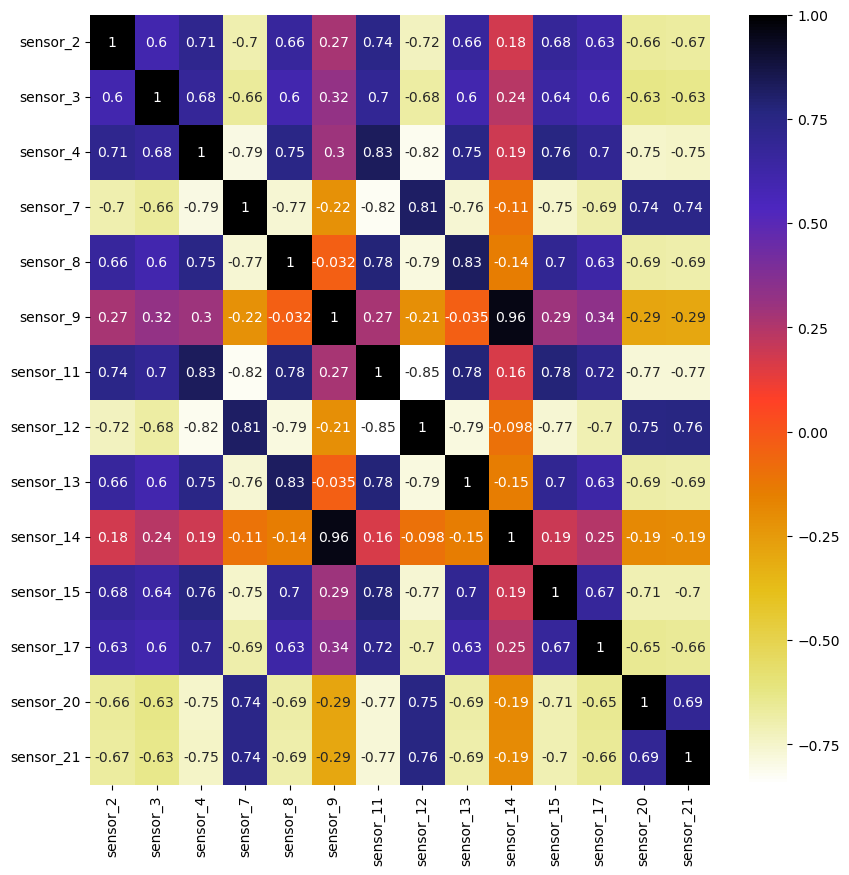

In [38]:
corr_matrix = x_train.corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, cmap=plt.cm.CMRmap_r)

In [39]:
def correlation(Dataset,Threshold):
    corrMatrix = Dataset.corr()
    num_features = len(Dataset.columns)
    corr = set()
    for i in range(num_features):
        for j in range(i):
            if abs(corrMatrix.iloc[i,j]) > Threshold :
                first_column_name = corrMatrix.columns[i]
                second_column_name = corrMatrix.columns[j]
                corr.add((first_column_name,second_column_name))
    
    return corr
Corr_Thre = 0.9
features_high_correlation = correlation(x_train,Corr_Thre)
print(f'Features With Higher Corralation than {Corr_Thre} : {features_high_correlation}')

Features With Higher Corralation than 0.9 : {('sensor_14', 'sensor_9')}


## Mutual Information Regression

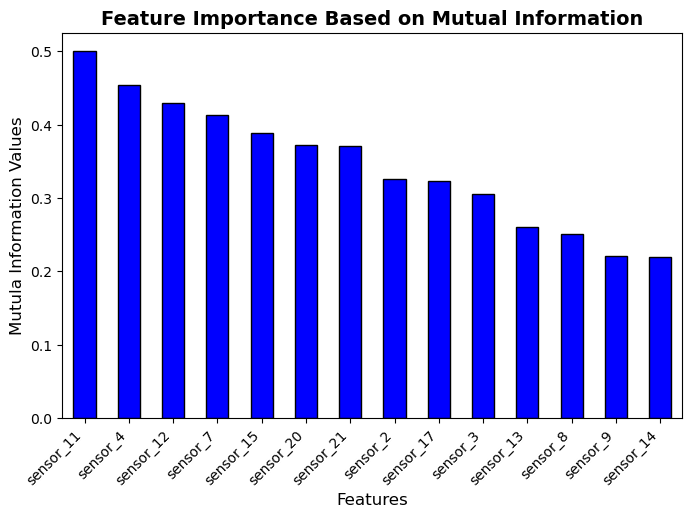

In [40]:
mutual_info_values = mutual_info_regression(x_train,y_train,random_state=42)
mutual_info = pd.Series(mutual_info_values, index=x_train.columns)
plot = mutual_info.sort_values(ascending=False).plot.bar(figsize=(8,5), color='blue', edgecolor='black')
plt.title('Feature Importance Based on Mutual Information', fontsize=14, weight='bold')
plt.xlabel('Features', fontsize = 12)
plt.ylabel('Mutula Information Values', fontsize = 12)
plt.xticks(rotation=45, ha='right')
plt.show()

#### A significant drop in values has not been shown, so we can not remove features after that drop. We can just choose N top important features.

In [41]:
score_func = lambda X, y : mutual_info_regression(X,y,random_state=42)
select_K_columns = SelectKBest(score_func,k=10)
select_K_columns.fit(x_train,y_train)
Selected_Features_MI = x_train.columns[select_K_columns.get_support()].to_list()
print('Top 10 Selected Features Based Mutual Information Scores:\n {}'.format(Selected_Features_MI))

Top 10 Selected Features Based Mutual Information Scores:
 ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


## Random Forest Regressor

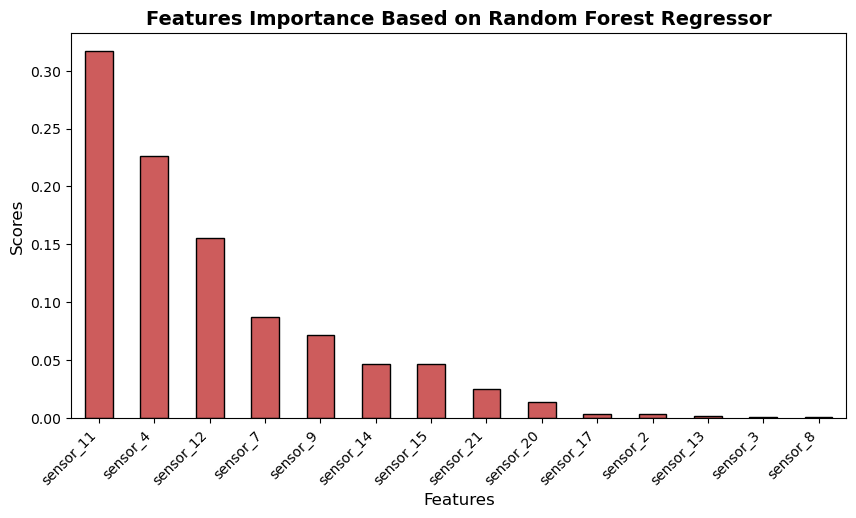

In [42]:
RFR_Features = RandomForestRegressor(n_estimators=400, max_depth=4, max_features=5 ,random_state=42, n_jobs=-1)
RFR_Features.fit(x_train,y_train)
Features_importance_RFR = pd.Series(RFR_Features.feature_importances_, index=x_train.columns)

Features_importance_RFR.sort_values(ascending=False).plot.bar(figsize=(10,5), color='indianred', edgecolor='black')
plt.title('Features Importance Based on Random Forest Regressor', fontsize=14, weight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

In [43]:
Selected_Features_RFR = Features_importance_RFR[Features_importance_RFR>0.01]
print('Selected Features Based RFR Scores:\n{}'.format(Selected_Features_RFR))

Selected Features Based RFR Scores:
sensor_4     0.226329
sensor_7     0.087450
sensor_9     0.071356
sensor_11    0.316714
sensor_12    0.155725
sensor_14    0.046790
sensor_15    0.046316
sensor_20    0.014123
sensor_21    0.024980
dtype: float64


## Lasso

In [44]:
tscv = TimeSeriesSplit(n_splits=5)
model_lasso = LassoCV(cv=tscv, random_state=42,n_jobs=-1, alphas=(0.001,0.01,0.1,1))
model_lasso.fit(x_train_norm,y_train_norm)

LassoCV(alphas=(0.001, 0.01, 0.1, 1),
        cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
        n_jobs=-1, random_state=42)

Best alpha: 0.0010


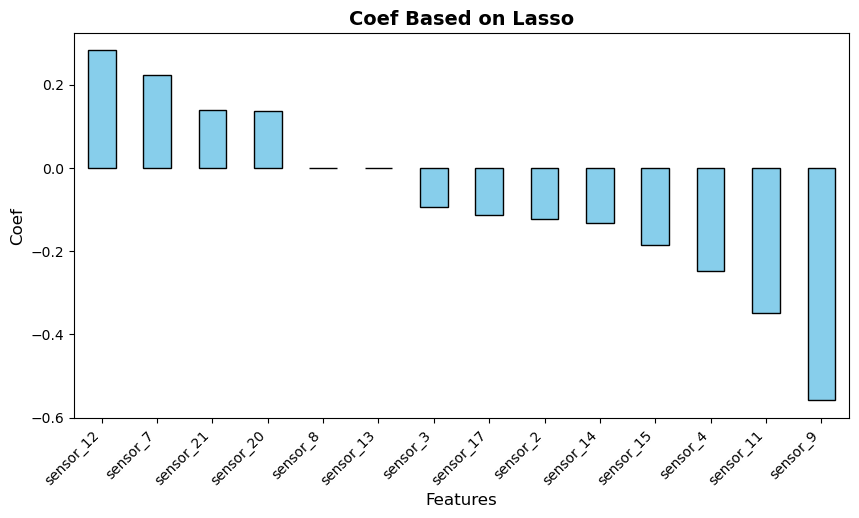

In [45]:
print(f'Best alpha: {model_lasso.alpha_:.4f}')
features_coef_lasso = pd.Series(model_lasso.coef_, index=x_train.columns)
features_coef_lasso.sort_values(ascending=False).plot.bar(figsize=(10,5), color='skyblue', edgecolor='black')
plt.title('Coef Based on Lasso', fontsize=14, weight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Coef', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

In [46]:
Selected_Features_Lasso = features_coef_lasso[abs(features_coef_lasso)>0.001]
print('Selected Features Based Lasso Coef:\n{}'.format(Selected_Features_Lasso))

Selected Features Based Lasso Coef:
sensor_2    -0.122423
sensor_3    -0.093531
sensor_4    -0.247261
sensor_7     0.222205
sensor_9    -0.558903
sensor_11   -0.349244
sensor_12    0.281814
sensor_14   -0.132809
sensor_15   -0.186361
sensor_17   -0.112708
sensor_20    0.136502
sensor_21    0.137904
dtype: float64


## Recursive Feature Elimination 

In [ ]:
model_RFR = RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1)
model_RFECV_RF = RFECV(estimator=model_RFR, scoring='neg_root_mean_squared_error', cv=tscv)
model_RFECV_RF.fit(x_train,y_train)

RFECV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
      estimator=RandomForestRegressor(n_estimators=250, n_jobs=-1,
                                      random_state=42),
      scoring='neg_root_mean_squared_error')

In [48]:
print('Best Scores: %s' % (model_RFECV_RF.cv_results_['mean_test_score'].max()))
print('Num Of Features: %s' % (model_RFECV_RF.n_features_))
print('Feature Ranking: %s' % (model_RFECV_RF.ranking_)) 
Selected_Features_RFECV_RF = model_RFECV_RF.get_feature_names_out()
print('Selected Feature names: %s' % (Selected_Features_RFECV_RF)) 

Best Scores: -19.43113212376263
Num Of Features: 14
Feature Ranking: [1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Selected Feature names: ['sensor_2' 'sensor_3' 'sensor_4' 'sensor_7' 'sensor_8' 'sensor_9'
 'sensor_11' 'sensor_12' 'sensor_13' 'sensor_14' 'sensor_15' 'sensor_17'
 'sensor_20' 'sensor_21']


In [ ]:
model_SVR = SVR(kernel='linear', C=1) 
model_RFECV_SVR = RFECV(estimator=model_SVR, scoring='neg_root_mean_squared_error', cv=tscv)
model_RFECV_SVR.fit(x_train_norm,y_train_norm)

RFECV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
      estimator=RandomForestRegressor(n_estimators=250, n_jobs=-1,
                                      random_state=42),
      scoring='neg_root_mean_squared_error')

In [50]:
print('Best Scores: %s' % (model_RFECV_SVR.cv_results_['mean_test_score'].max()))
print('Num Of Features: %s' % (model_RFECV_SVR.n_features_))
print('Feature Ranking: %s' % (model_RFECV_SVR.ranking_)) 
Selected_Features_RFECV_SVR = model_RFECV_SVR.get_feature_names_out()
print('Selected Feature names: %s' % (Selected_Features_RFECV_SVR)) 

Best Scores: -0.15536928897500787
Num Of Features: 14
Feature Ranking: [1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Selected Feature names: ['sensor_2' 'sensor_3' 'sensor_4' 'sensor_7' 'sensor_8' 'sensor_9'
 'sensor_11' 'sensor_12' 'sensor_13' 'sensor_14' 'sensor_15' 'sensor_17'
 'sensor_20' 'sensor_21']


## Sequential Feature Selector

In [51]:
model_SVR_RBF = SVR(kernel='rbf', C=1)
model_SFS_SVR = SFS(estimator=model_SVR_RBF, k_features='best', cv=tscv, scoring='neg_root_mean_squared_error',
                    n_jobs=-1, forward=True, floating=True)

model_SFS_SVR.fit(x_train_norm,y_train_norm)

SequentialFeatureSelector(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                          estimator=SVR(C=1), floating=True, k_features=(1, 14),
                          n_jobs=-1, scoring='neg_root_mean_squared_error')

In [52]:
print(f'Best score: {model_SFS_SVR.k_score_}')
print(f'Num Of Features: {len(model_SFS_SVR.k_feature_names_)}')
Selected_Features_SFS_SVR = model_SFS_SVR.k_feature_names_
print(f'Selected feature names: {Selected_Features_SFS_SVR}')
pd.DataFrame.from_dict(model_SFS_SVR.get_metric_dict()).T

Best score: -0.15194732682434503
Num Of Features: 13
Selected feature names: ('sensor_2', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21')


,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
1,"(6,)","[-0.2144546633110222, -0.19739463478244462, -0...",-0.204934,"(sensor_11,)",0.011101,0.008637,0.004318
2,"(5, 6)","[-0.17917116907403244, -0.15754586349191363, -...",-0.176574,"(sensor_9, sensor_11)",0.015699,0.012214,0.006107
3,"(5, 6, 7)","[-0.16421515442020207, -0.14264045374217688, -...",-0.164381,"(sensor_9, sensor_11, sensor_12)",0.018925,0.014724,0.007362
4,"(5, 6, 7, 8)","[-0.1590459649774756, -0.1375006585743923, -0....",-0.159504,"(sensor_9, sensor_11, sensor_12, sensor_13)",0.019379,0.015078,0.007539
5,"(2, 5, 6, 7, 8)","[-0.1555088385736287, -0.13581307027780104, -0...",-0.156907,"(sensor_4, sensor_9, sensor_11, sensor_12, sen...",0.019406,0.015099,0.007549
6,"(2, 3, 5, 6, 7, 8)","[-0.15359061261042237, -0.13415178236908037, -...",-0.15517,"(sensor_4, sensor_7, sensor_9, sensor_11, sens...",0.019938,0.015512,0.007756
7,"(2, 3, 5, 6, 7, 8, 10)","[-0.15228336551861227, -0.13303622215884978, -...",-0.154273,"(sensor_4, sensor_7, sensor_9, sensor_11, sens...",0.020321,0.01581,0.007905
8,"(2, 3, 5, 6, 7, 8, 9, 10)","[-0.15230967256207484, -0.13069996685851945, -...",-0.153853,"(sensor_4, sensor_7, sensor_9, sensor_11, sens...",0.021064,0.016388,0.008194
9,"(2, 3, 4, 5, 6, 7, 8, 9, 10)","[-0.15121882344728962, -0.13038935871153037, -...",-0.152974,"(sensor_4, sensor_7, sensor_8, sensor_9, senso...",0.020786,0.016172,0.008086
10,"(2, 3, 4, 5, 6, 7, 8, 9, 10, 12)","[-0.15089994906204637, -0.1301325902247653, -0...",-0.152708,"(sensor_4, sensor_7, sensor_8, sensor_9, senso...",0.020988,0.016329,0.008165


### Selected Features With Different Methods

In [53]:
print(f'Features With Higher Corralation than {Corr_Thre} : {features_high_correlation}\n')

print('Top 10 Selected Features Based Mutual Information Scores:\n {}\n'.format(Selected_Features_MI))

print('Selected Features Based RFR Scores:\n{}\n'.format(Selected_Features_RFR.index.to_list()))

print('Selected Features Based Lasso Coef:\n{}\n'.format(Selected_Features_Lasso.index.to_list()))

print('Selected Feature Based RFECV_RF:\n{}\n'.format(Selected_Features_RFECV_RF)) 

print('Selected Feature Based RFECV_SVR:\n{}\n'.format(Selected_Features_RFECV_SVR)) 

print('Selected feature Based SFS_SVR:\n{}\n'.format(Selected_Features_SFS_SVR))

Features With Higher Corralation than 0.9 : {('sensor_14', 'sensor_9')}

Top 10 Selected Features Based Mutual Information Scores:
 ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Selected Features Based RFR Scores:
['sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_15', 'sensor_20', 'sensor_21']

Selected Features Based Lasso Coef:
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Selected Feature Based RFECV_RF:
['sensor_2' 'sensor_3' 'sensor_4' 'sensor_7' 'sensor_8' 'sensor_9'
 'sensor_11' 'sensor_12' 'sensor_13' 'sensor_14' 'sensor_15' 'sensor_17'
 'sensor_20' 'sensor_21']

Selected Feature Based RFECV_SVR:
['sensor_2' 'sensor_3' 'sensor_4' 'sensor_7' 'sensor_8' 'sensor_9'
 'sensor_11' 'sensor_12' 'sensor_13' 'sensor_14' 'sensor_15' 'sensor_17'
 'sensor_20' 'sensor_21']

#### sensor_14 and sensor_9 have a high correlation and i decide to remove sensor_14 

In [56]:
x_train_RFR = x_train[[x for x in Selected_Features_RFR.index.to_list() if x != 'sensor_14']]
x_train_SFS_SVR = x_train[[x for x in Selected_Features_SFS_SVR if x != 'sensor_14']]

x_test_RFR = x_test[[x for x in Selected_Features_RFR.index.to_list() if x != 'sensor_14']]
x_test_SFS_SVR = x_test[[x for x in Selected_Features_SFS_SVR if x != 'sensor_14']]

In [57]:
x_train_RFR.to_csv('x_train_RFR.csv',index=False)
x_test_RFR.to_csv('x_test_RFR.csv',index=False)

x_train_SFS_SVR.to_csv('x_train_SFS_SVR.csv',index=False)
x_test_SFS_SVR.to_csv('x_test_SFS_SVR.csv',index=False)

x_train.to_csv('x_train.csv',index=False)
x_test.to_csv('x_test.csv',index=False)

y_train.to_csv('y_train.csv',index=False)
df_RUL_Test_Data.to_csv('y_test.csv',index=False)